In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import joblib, os, json, time

# Global style
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#333333",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "savefig.bbox": "tight",
})

PALETTE = {
    "primary":  "#2c7fb8",
    "accent":   "#e6550d",
    "success":  "#31a354",
    "danger":   "#d62728",
    "warning":  "#fec44f",
    "neutral":  "#636363",
    "purple":   "#756bb1",
}
CLASS_COLORS = {0: "#31a354", 1: "#fec44f", 2: "#d62728"}  # LOW, MED, HIGH
CLASS_NAMES = ["LOW", "MEDIUM", "HIGH"]

os.makedirs("../figures/classification", exist_ok=True)
os.makedirs("../models", exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

with open("../models/feature_cols.json") as f:
    meta = json.load(f)
feature_cols = meta["features"]
target_col   = meta["target"]

print(f"Train: {train.shape}  Val: {val.shape}  Test: {test.shape}")
print(f"Features: {len(feature_cols)}  Target base: {target_col}")

Train: (34541, 48)  Val: (7402, 48)  Test: (7402, 48)
Features: 39  Target base: avg_return_temp


In [3]:
# Use percentiles so classes are balanced AND thresholds adapt to the data
low_thresh  = float(train["avg_return_temp"].quantile(0.30))   # ~30th pct
high_thresh = float(train["avg_return_temp"].quantile(0.90))   # ~90th pct

LOW_THRESH  = round(low_thresh, 2)
HIGH_THRESH = round(high_thresh, 2)

print(f"Computed thresholds from training data:")
print(f"  LOW    < {LOW_THRESH} °C")
print(f"  MEDIUM   {LOW_THRESH} – {HIGH_THRESH} °C")
print(f"  HIGH   > {HIGH_THRESH} °C")

def make_risk_label(x):
    if x < LOW_THRESH:      return 0
    elif x <= HIGH_THRESH:  return 1
    else:                   return 2

def add_risk_labels(df, target_col="avg_return_temp"):
    df = df.copy()
    df["next_return_temp"] = df[target_col].shift(-1)
    df["risk"] = df["next_return_temp"].apply(make_risk_label)
    return df.dropna(subset=["next_return_temp", "risk"])

train_r = add_risk_labels(train)
val_r   = add_risk_labels(val)
test_r  = add_risk_labels(test)

print("\nLabel counts (train):")
print(train_r["risk"].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES))))
print("\nLabel proportions (train):")
print(train_r["risk"].value_counts(normalize=True).sort_index().round(3).rename(index=dict(enumerate(CLASS_NAMES))))

Computed thresholds from training data:
  LOW    < 29.37 °C
  MEDIUM   29.37 – 36.53 °C
  HIGH   > 36.53 °C

Label counts (train):
risk
LOW       10356
MEDIUM    20735
HIGH       3449
Name: count, dtype: int64

Label proportions (train):
risk
LOW       0.3
MEDIUM    0.6
HIGH      0.1
Name: proportion, dtype: float64


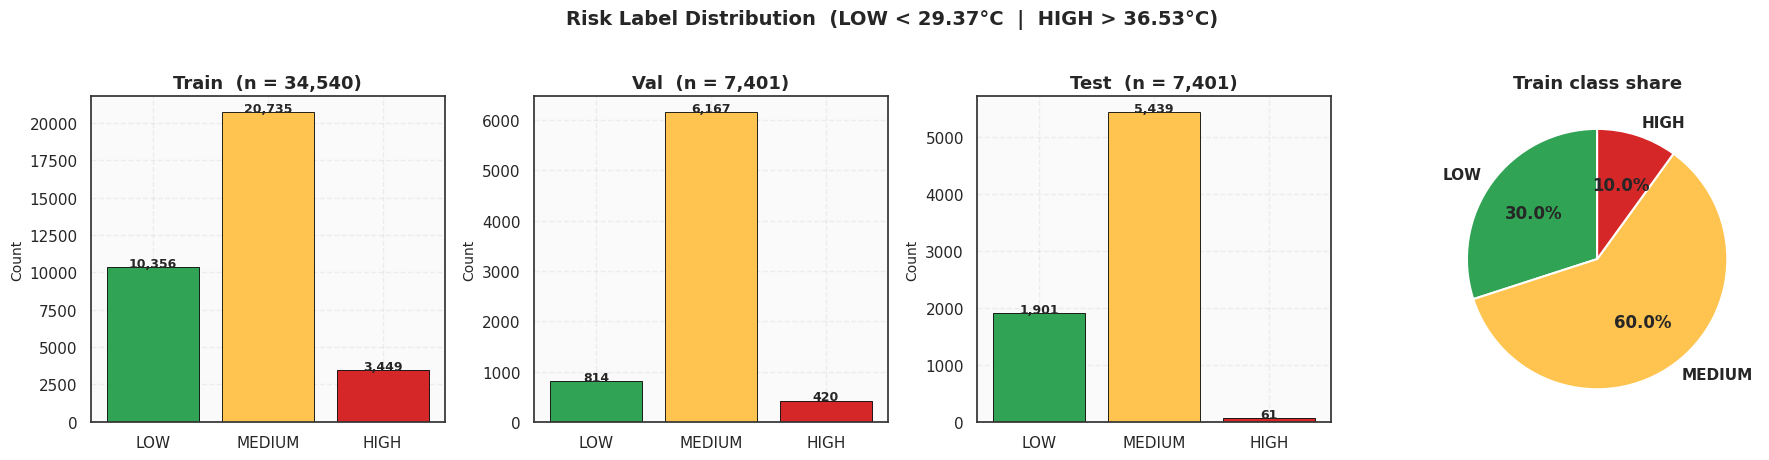

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

splits = [("Train", train_r, PALETTE["primary"]),
          ("Val",   val_r,   PALETTE["accent"]),
          ("Test",  test_r,  PALETTE["danger"])]

for ax, (name, d, c) in zip(axes[:3], splits):
    counts = d["risk"].value_counts().sort_index()
    bars = ax.bar(CLASS_NAMES, counts.values,
                  color=[CLASS_COLORS[i] for i in counts.index],
                  edgecolor="black", linewidth=0.6)
    ax.set_title(f"{name}  (n = {len(d):,})")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{v:,}", ha="center", fontweight="bold", fontsize=9)

# Pie for train
ax = axes[3]
counts = train_r["risk"].value_counts().sort_index()
ax.pie(counts.values, labels=CLASS_NAMES, autopct="%1.1f%%",
       colors=[CLASS_COLORS[i] for i in counts.index],
       wedgeprops={"edgecolor": "white", "linewidth": 1.5},
       startangle=90, textprops={"fontweight": "bold"})
ax.set_title("Train class share")

plt.suptitle(f"Risk Label Distribution  (LOW < {LOW_THRESH}°C  |  HIGH > {HIGH_THRESH}°C)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/classification/01_class_distribution.png", dpi=150)
plt.show()

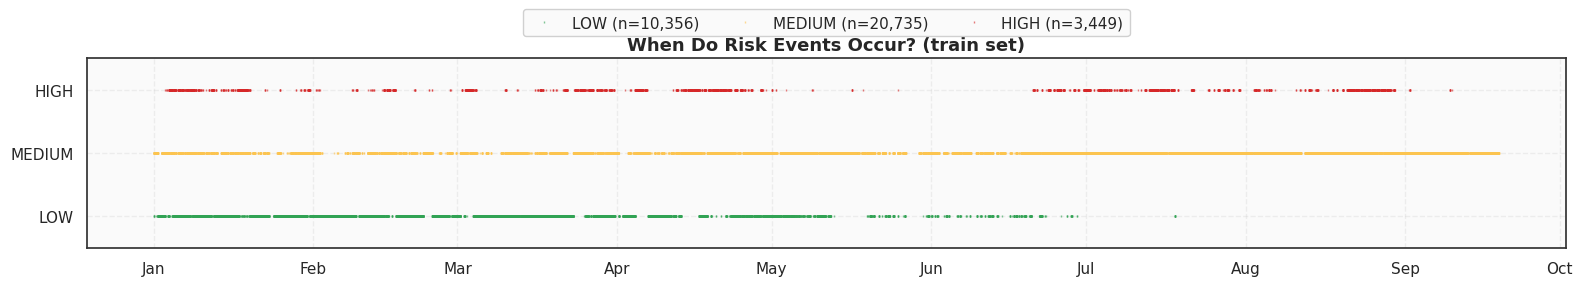

In [5]:
fig, ax = plt.subplots(figsize=(16, 3.2))

for cls, color in CLASS_COLORS.items():
    subset = train_r[train_r["risk"] == cls]
    ax.plot(subset["timestamp"], np.full(len(subset), cls), "|",
            ms=1.5, color=color, alpha=0.6, label=f"{CLASS_NAMES[cls]} (n={len(subset):,})")

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(CLASS_NAMES)
ax.set_ylim(-0.5, 2.5)
ax.set_title("When Do Risk Events Occur? (train set)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.3))
plt.tight_layout()
plt.savefig("../figures/classification/02_risk_over_time.png", dpi=150)
plt.show()

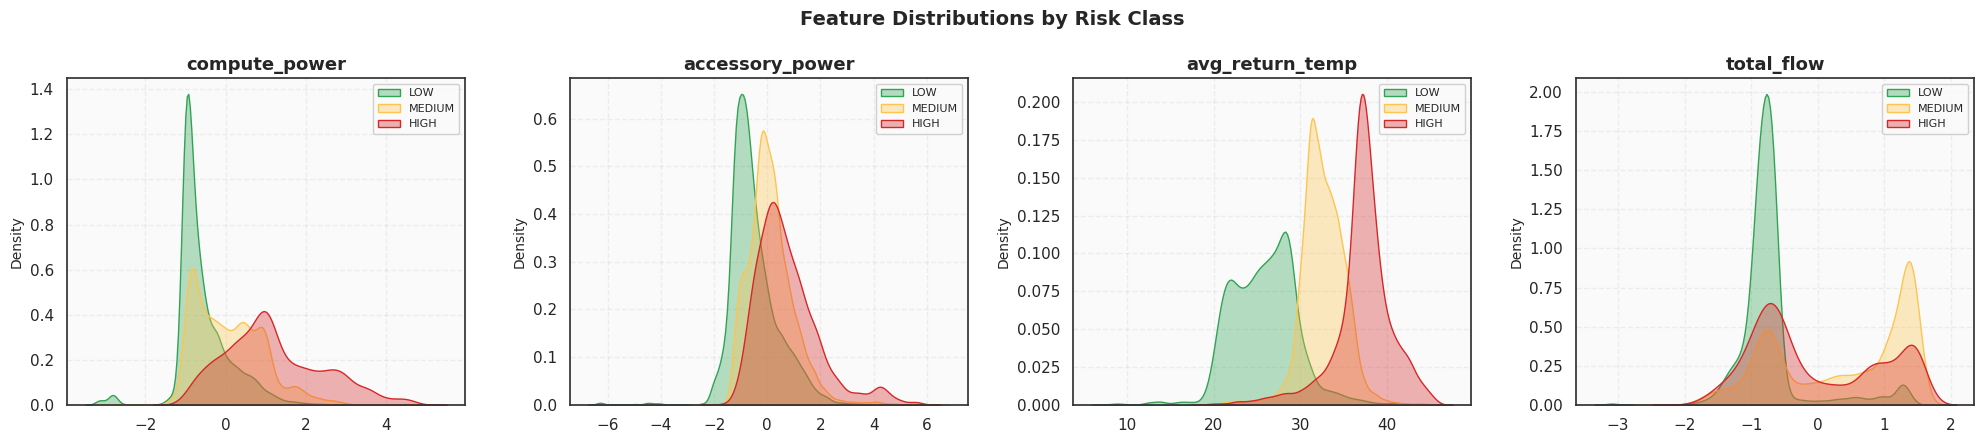

In [6]:
key_feats = ["compute_power", "accessory_power", "avg_return_temp", "total_flow"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, feat in zip(axes, key_feats):
    for cls in [0, 1, 2]:
        sns.kdeplot(train_r.loc[train_r["risk"] == cls, feat],
                    ax=ax, fill=True, alpha=0.35,
                    color=CLASS_COLORS[cls], label=CLASS_NAMES[cls])
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions by Risk Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/classification/03_class_conditional_dist.png", dpi=150)
plt.show()

In [7]:
X_train, y_train = train_r[feature_cols].values, train_r["risk"].values
X_val,   y_val   = val_r[feature_cols].values,   val_r["risk"].values
X_test,  y_test  = test_r[feature_cols].values,  test_r["risk"].values

# Compute class weights for imbalanced learning
classes, counts = np.unique(y_train, return_counts=True)
class_weights = {c: len(y_train) / (len(classes) * n) for c, n in zip(classes, counts)}
sample_weights = np.array([class_weights[y] for y in y_train])
print("Class weights:", {CLASS_NAMES[c]: round(w, 3) for c, w in class_weights.items()})

classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000,
                                             class_weight="balanced"),
    "RandomForest":       RandomForestClassifier(n_estimators=300,
                                                 class_weight="balanced",
                                                 n_jobs=-1, random_state=42),
    "XGBoost":            XGBClassifier(n_estimators=300, max_depth=6,
                                        learning_rate=0.05, eval_metric="mlogloss",
                                        random_state=42, n_jobs=-1),
}

results = {}
for name, clf in classifiers.items():
    t0 = time.time()
    if name == "XGBoost":
        clf.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        clf.fit(X_train, y_train)
    train_time = time.time() - t0

    preds = clf.predict(X_test)
    proba = clf.predict_proba(X_test)

    results[name] = {
        "model":      clf,
        "preds":      preds,
        "proba":      proba,
        "acc":        accuracy_score(y_test, preds),
        "f1_macro":   f1_score(y_test, preds, average="macro"),
        "f1_weighted":f1_score(y_test, preds, average="weighted"),
        "auc":        roc_auc_score(label_binarize(y_test, classes=[0,1,2]),
                                    proba, multi_class="ovr", average="macro"),
        "train_time": train_time,
    }
    print(f"{name:20s}  acc={results[name]['acc']:.4f}  "
          f"F1m={results[name]['f1_macro']:.4f}  "
          f"AUC={results[name]['auc']:.4f}  "
          f"({train_time:.1f}s)")

Class weights: {'LOW': np.float64(1.112), 'MEDIUM': np.float64(0.555), 'HIGH': np.float64(3.338)}
LogisticRegression    acc=0.7356  F1m=0.5203  AUC=0.8323  (9.6s)
RandomForest          acc=0.8479  F1m=0.5793  AUC=0.8540  (8.0s)
XGBoost               acc=0.8360  F1m=0.5867  AUC=0.8412  (6.5s)


                    Accuracy  F1 (macro)  F1 (weighted)  AUC (macro)  \
LogisticRegression    0.7356      0.5203         0.7574       0.8323   
RandomForest          0.8479      0.5793         0.8353       0.8540   
XGBoost               0.8360      0.5867         0.8399       0.8412   

                    Train time (s)  
LogisticRegression            9.59  
RandomForest                  8.03  
XGBoost                       6.53  


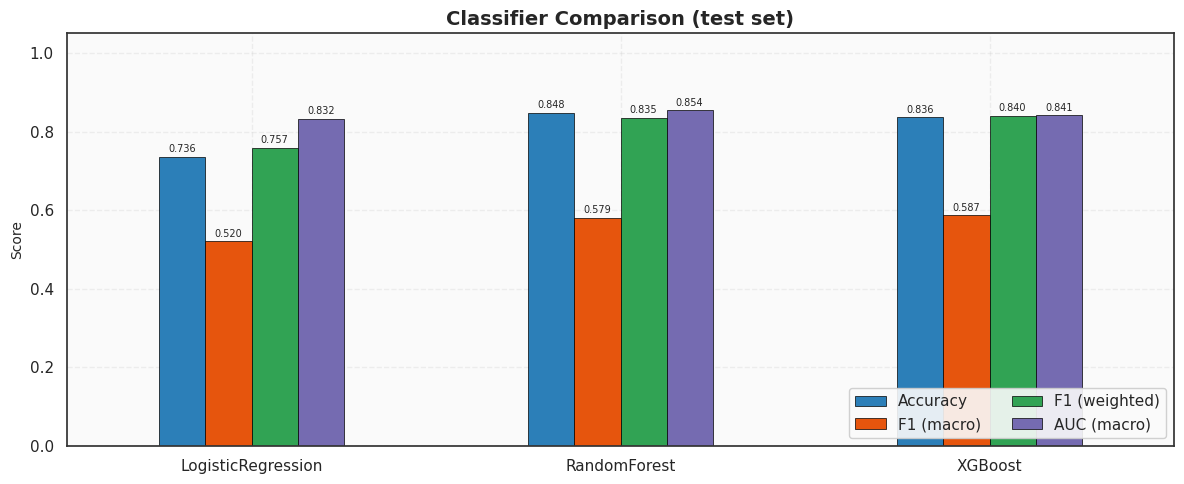

In [8]:
df_res = pd.DataFrame({
    name: {
        "Accuracy":     r["acc"],
        "F1 (macro)":   r["f1_macro"],
        "F1 (weighted)":r["f1_weighted"],
        "AUC (macro)":  r["auc"],
        "Train time (s)": round(r["train_time"], 2),
    }
    for name, r in results.items()
}).T.round(4)

print(df_res)

# Bar chart
metrics = ["Accuracy", "F1 (macro)", "F1 (weighted)", "AUC (macro)"]

fig, ax = plt.subplots(figsize=(12, 5))
df_res[metrics].plot(kind="bar", ax=ax,
                     color=[PALETTE["primary"], PALETTE["accent"],
                            PALETTE["success"], PALETTE["purple"]],
                     edgecolor="black", linewidth=0.5)
ax.set_ylim(0, 1.05)
ax.set_title("Classifier Comparison (test set)", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right", ncol=2)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
plt.tight_layout()
plt.savefig("../figures/classification/04_classifier_comparison.png", dpi=150)
plt.show()

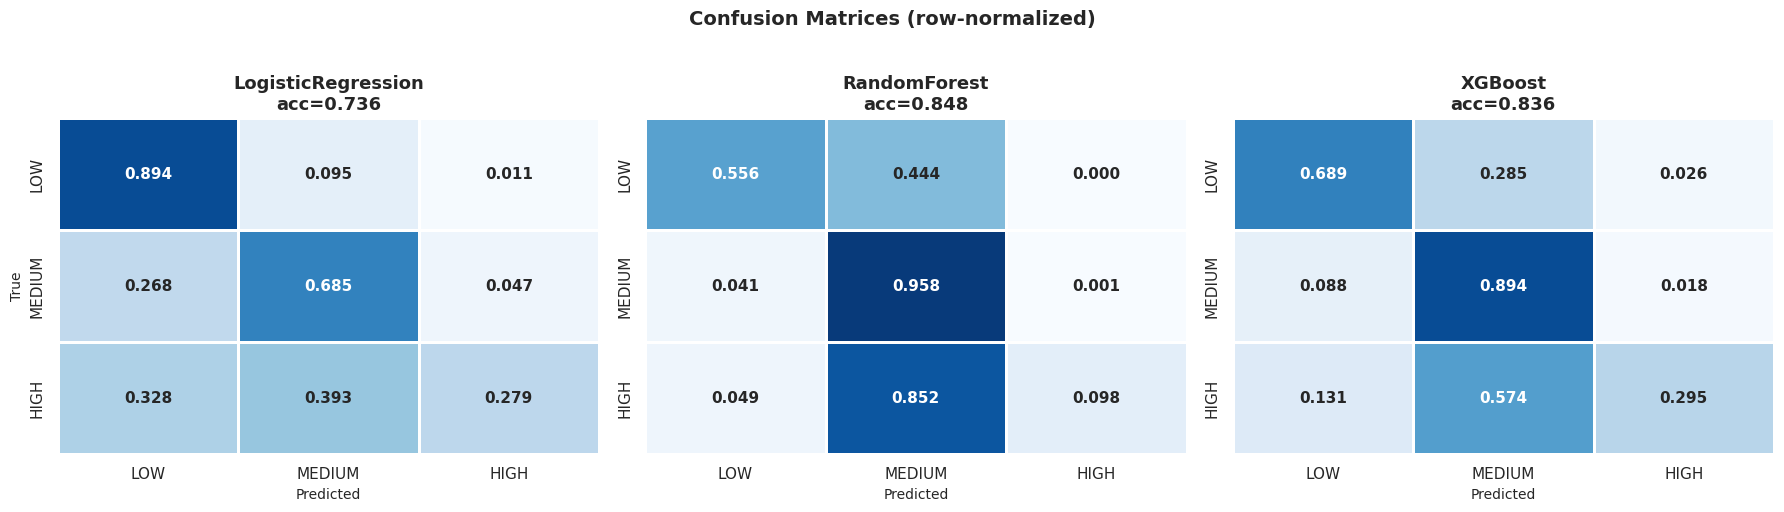

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["preds"], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, cbar=False, linewidths=1, linecolor="white",
                annot_kws={"fontsize": 11, "fontweight": "bold"}, ax=ax)
    ax.set_title(f"{name}\nacc={r['acc']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if name == list(results.keys())[0] else "")

plt.suptitle("Confusion Matrices (row-normalized)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/classification/05_confusion_matrices.png", dpi=150)
plt.show()

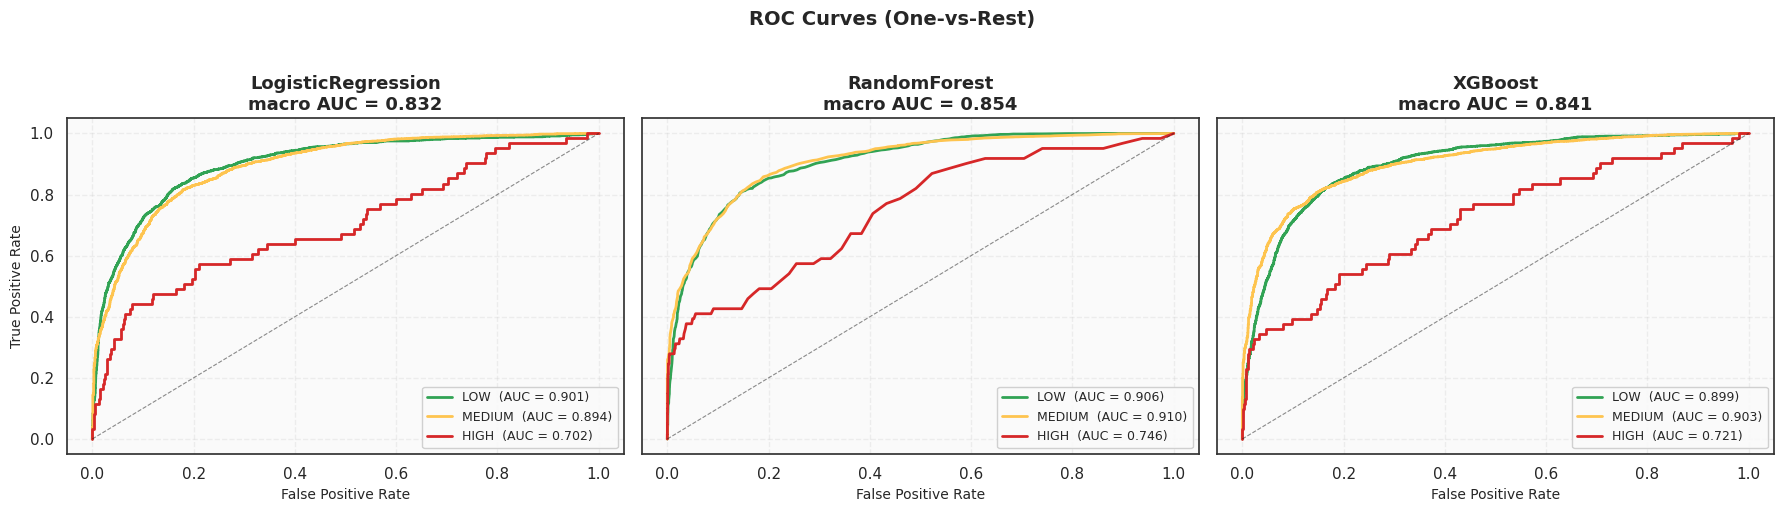

In [10]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, r) in zip(axes, results.items()):
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], r["proba"][:, i])
        auc_i = roc_auc_score(y_test_bin[:, i], r["proba"][:, i])
        ax.plot(fpr, tpr, lw=2, color=CLASS_COLORS[i],
                label=f"{cls}  (AUC = {auc_i:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    ax.set_title(f"{name}\nmacro AUC = {r['auc']:.3f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate" if name == list(results.keys())[0] else "")
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/classification/06_roc_curves.png", dpi=150)
plt.show()

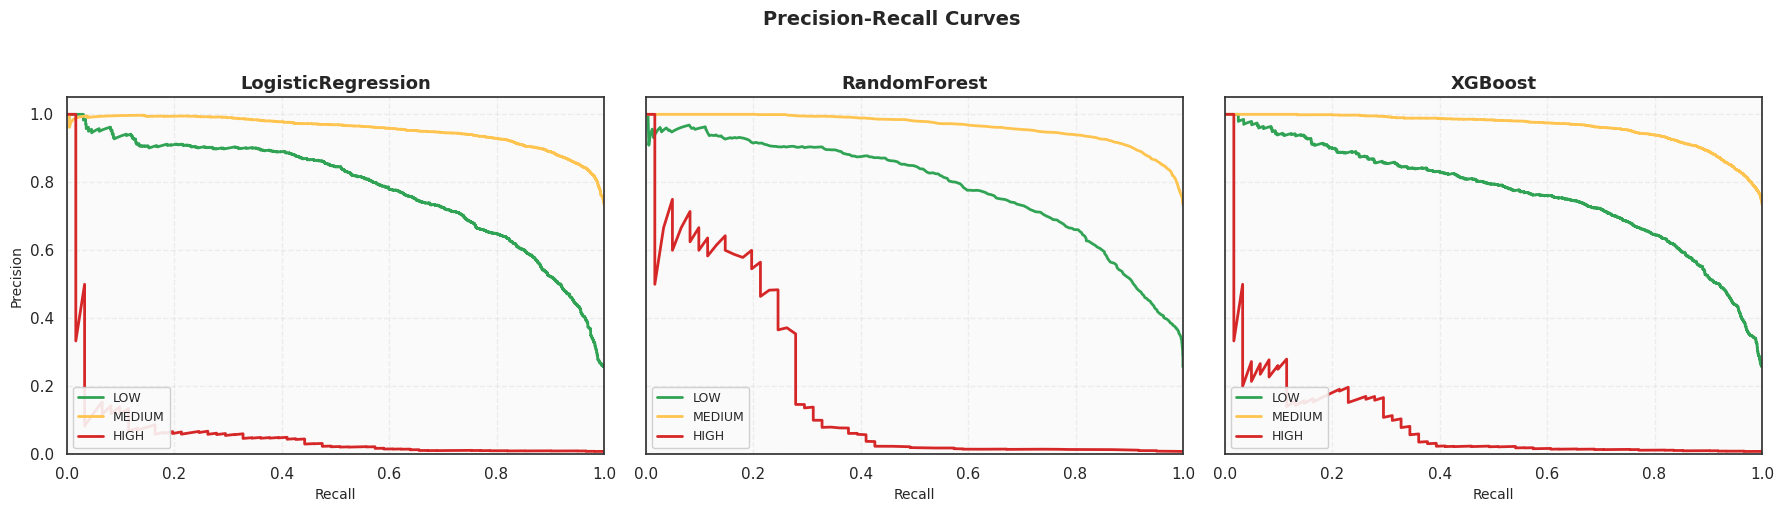

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, r) in zip(axes, results.items()):
    for i, cls in enumerate(CLASS_NAMES):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, i], r["proba"][:, i])
        ax.plot(rec, prec, lw=2, color=CLASS_COLORS[i], label=cls)
    ax.set_title(f"{name}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision" if name == list(results.keys())[0] else "")
    ax.legend(loc="lower left", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

plt.suptitle("Precision-Recall Curves", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/classification/07_precision_recall.png", dpi=150)
plt.show()

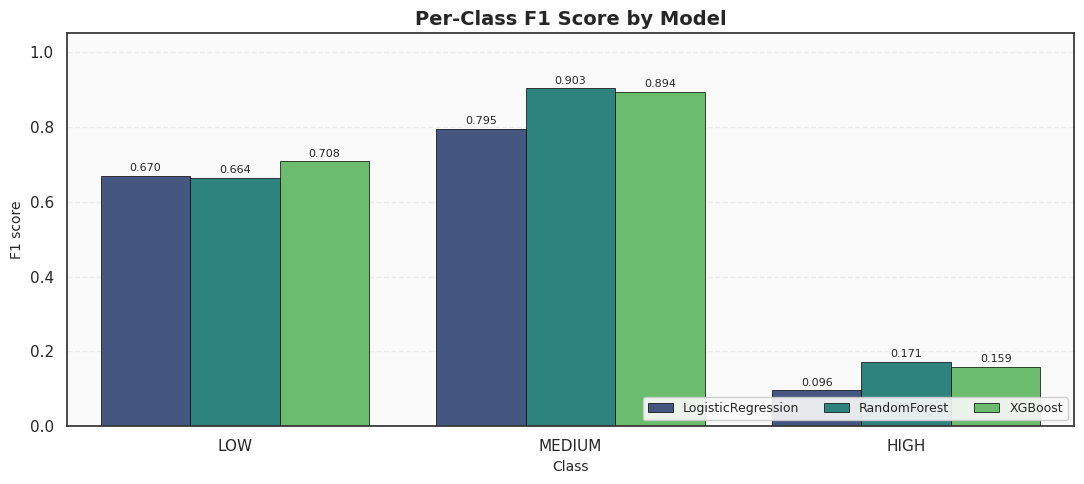

In [12]:
rows = []
for name, r in results.items():
    f1_per = f1_score(y_test, r["preds"], average=None)
    for i, cls in enumerate(CLASS_NAMES):
        rows.append({"Model": name, "Class": cls, "F1": f1_per[i]})

f1_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=f1_df, x="Class", y="F1", hue="Model",
            palette="viridis", edgecolor="black", linewidth=0.5, ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1 Score by Model", fontsize=14, fontweight="bold")
ax.set_ylabel("F1 score")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
ax.legend(loc="lower right", ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("../figures/classification/08_per_class_f1.png", dpi=150)
plt.show()

In [13]:
best_name = max(results, key=lambda k: results[k]["f1_macro"])
print(f"Best classifier (macro-F1): {best_name}\n")
print(classification_report(y_test, results[best_name]["preds"],
                            target_names=CLASS_NAMES, digits=4))

Best classifier (macro-F1): XGBoost

              precision    recall  f1-score   support

         LOW     0.7280    0.6886    0.7078      1901
      MEDIUM     0.8939    0.8935    0.8937      5439
        HIGH     0.1084    0.2951    0.1586        61

    accuracy                         0.8360      7401
   macro avg     0.5768    0.6257    0.5867      7401
weighted avg     0.8448    0.8360    0.8399      7401



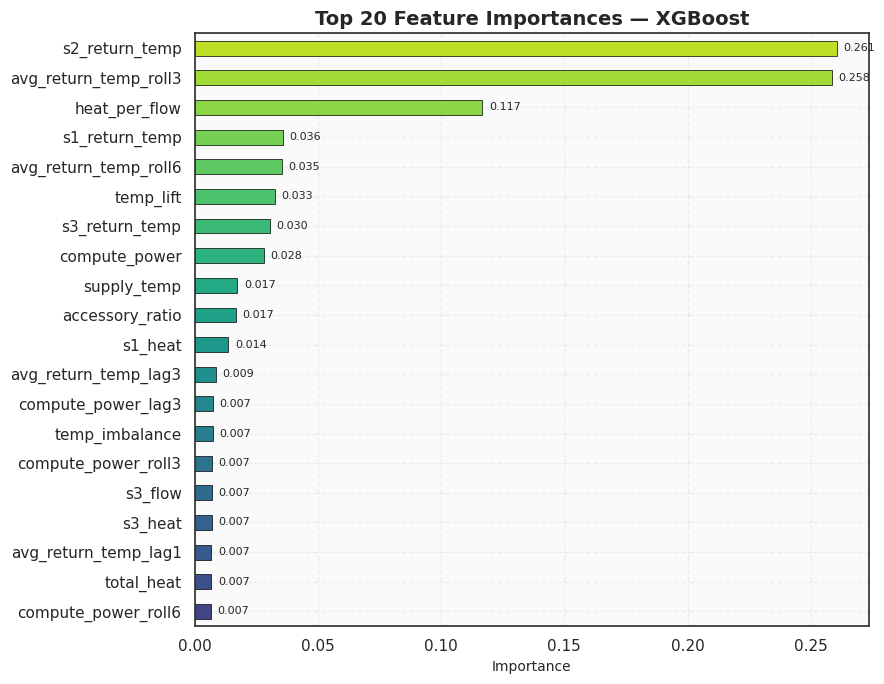

In [14]:
best_tree = None
for name in ["XGBoost", "RandomForest"]:
    if hasattr(results[name]["model"], "feature_importances_"):
        best_tree = (name, results[name]["model"])
        break

if best_tree:
    name, model = best_tree
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp)))[::-1]
    imp.plot(kind="barh", ax=ax, color=colors, edgecolor="black", linewidth=0.5)
    ax.invert_yaxis()
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 20 Feature Importances — {name}", fontsize=14, fontweight="bold")
    for i, (v, label) in enumerate(zip(imp.values, imp.index)):
        ax.text(v + max(imp)*0.01, i, f"{v:.3f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("../figures/classification/09_feature_importance.png", dpi=150)
    plt.show()

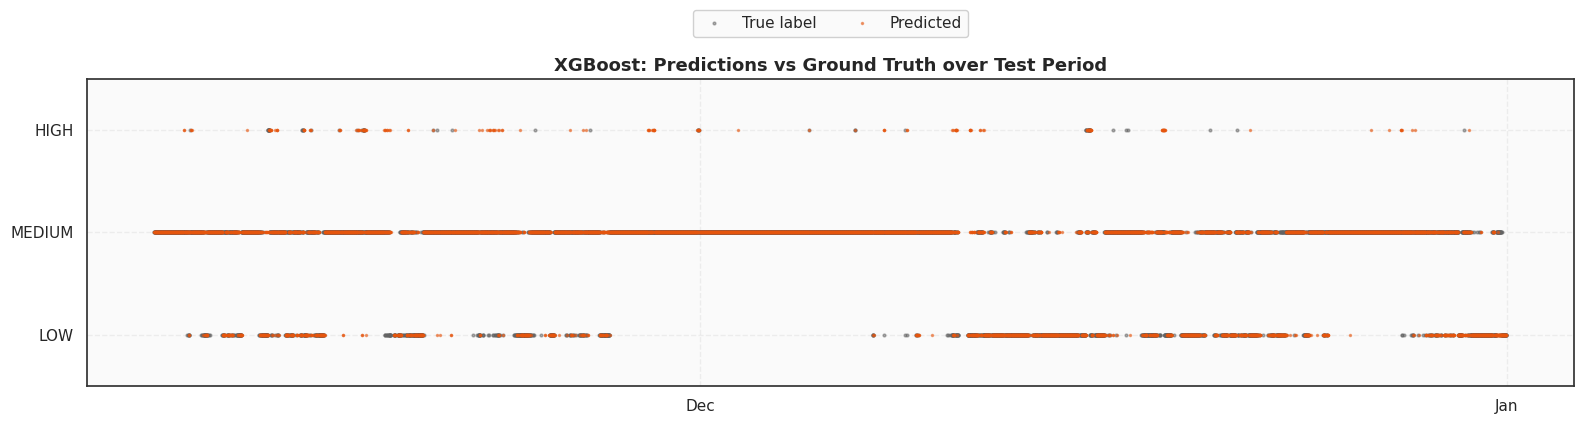

In [15]:
best = results[best_name]

fig, ax = plt.subplots(figsize=(16, 4.5))

test_times = test_r["timestamp"].values
ax.plot(test_times, test_r["risk"].values, ".", ms=4,
        color=PALETTE["neutral"], label="True label", alpha=0.5)
ax.plot(test_times, best["preds"], ".", ms=3,
        color=PALETTE["accent"], label="Predicted", alpha=0.5)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(CLASS_NAMES)
ax.set_ylim(-0.5, 2.5)
ax.set_title(f"{best_name}: Predictions vs Ground Truth over Test Period")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.25))
plt.tight_layout()
plt.savefig("../figures/classification/10_predictions_over_time.png", dpi=150)
plt.show()

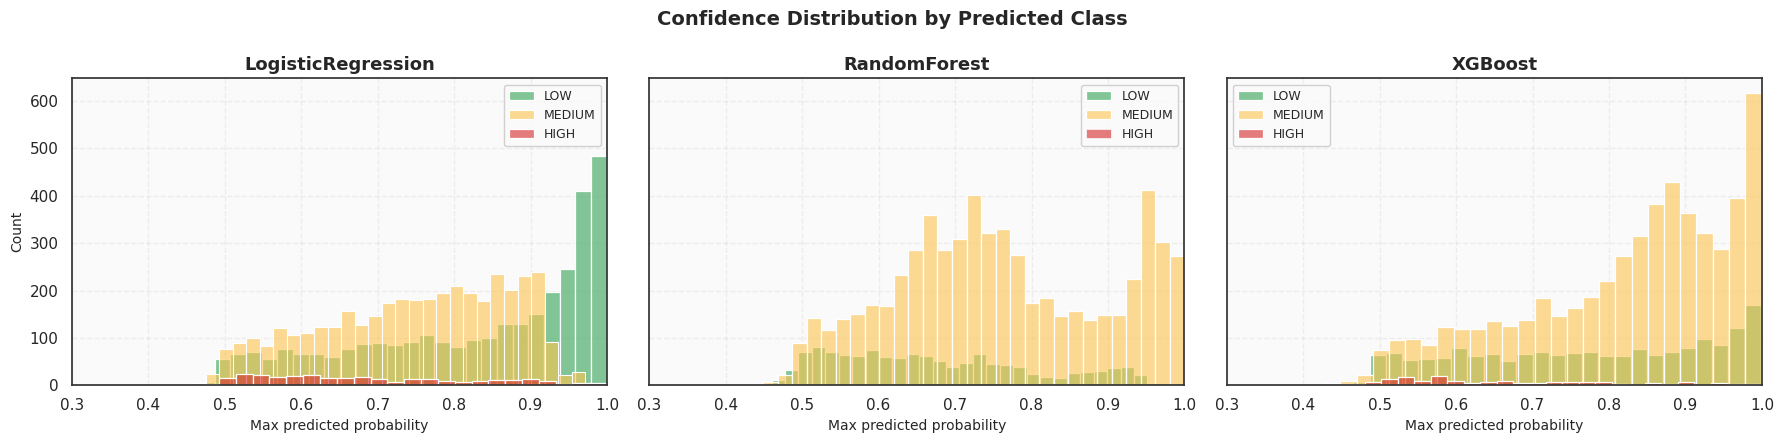

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

for ax, (name, r) in zip(axes, results.items()):
    max_proba = r["proba"].max(axis=1)
    for i, cls in enumerate(CLASS_NAMES):
        mask = r["preds"] == i
        if mask.sum():
            sns.histplot(max_proba[mask], bins=30, ax=ax,
                         color=CLASS_COLORS[i], label=cls,
                         alpha=0.6, edgecolor="white")
    ax.set_title(f"{name}")
    ax.set_xlabel("Max predicted probability")
    ax.set_xlim(0.3, 1.0)
    ax.legend(fontsize=9)

plt.suptitle("Confidence Distribution by Predicted Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/classification/11_confidence.png", dpi=150)
plt.show()

Total errors: 1,214 / 7,401  (16.40%)

True (rows) vs Predicted (cols):
        LOW  MEDIUM  HIGH
LOW       0     542    50
MEDIUM  481       0    98
HIGH      8      35     0


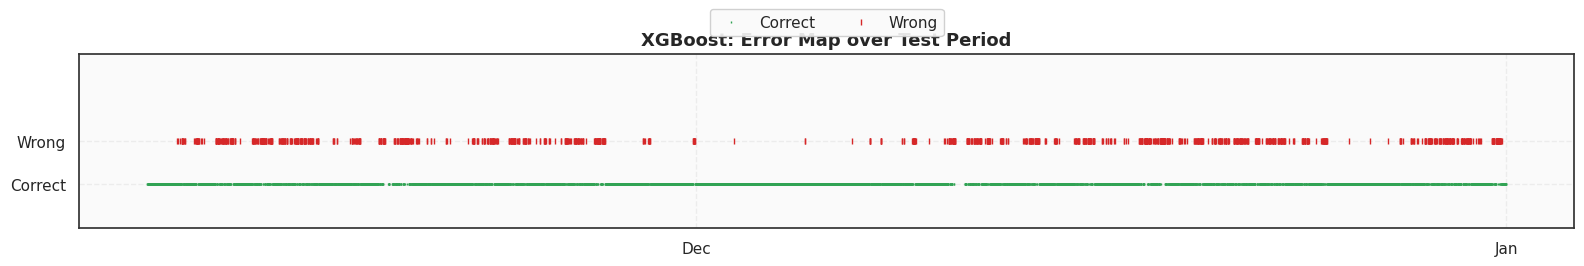

In [17]:
best = results[best_name]
errors = test_r[best["preds"] != y_test]

print(f"Total errors: {len(errors):,} / {len(test_r):,}  "
      f"({len(errors)/len(test_r)*100:.2f}%)")

# Breakdown
err_table = pd.crosstab(
    test_r.loc[best["preds"] != y_test, "risk"],
    pd.Series(best["preds"][best["preds"] != y_test], index=errors.index),
)
err_table.index = [CLASS_NAMES[i] for i in err_table.index]
err_table.columns = [CLASS_NAMES[i] for i in err_table.columns]
print("\nTrue (rows) vs Predicted (cols):")
print(err_table)

# Visualize error map on timeline
fig, ax = plt.subplots(figsize=(16, 3))
correct = test_r["timestamp"][best["preds"] == y_test]
wrong   = test_r["timestamp"][best["preds"] != y_test]
ax.plot(correct, np.ones(len(correct)), "|", ms=2, color=PALETTE["success"], label="Correct")
ax.plot(wrong,   np.ones(len(wrong))*1.1, "|", ms=4, color=PALETTE["danger"], label="Wrong")
ax.set_yticks([1.0, 1.1]); ax.set_yticklabels(["Correct", "Wrong"])
ax.set_ylim(0.9, 1.3)
ax.set_title(f"{best_name}: Error Map over Test Period")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.3))
plt.tight_layout()
plt.savefig("../figures/classification/12_error_map.png", dpi=150)
plt.show()

In [18]:
summary = {
    "Risk thresholds":  f"LOW <{LOW_THRESH}°C, MED {LOW_THRESH}-{HIGH_THRESH}°C, HIGH >{HIGH_THRESH}°C",
    "Train samples":    f"{len(train_r):,}",
    "Val samples":      f"{len(val_r):,}",
    "Test samples":     f"{len(test_r):,}",
    "Features":         f"{len(feature_cols)}",
    "Models compared":  ", ".join(results.keys()),
    "Best model (F1m)": best_name,
    "Best accuracy":    f"{results[best_name]['acc']:.4f}",
    "Best F1 (macro)":  f"{results[best_name]['f1_macro']:.4f}",
    "Best AUC (macro)": f"{results[best_name]['auc']:.4f}",
}

In [19]:
model_path = f"../models/best_classifier_{best_name}.pkl"
joblib.dump(results[best_name]["model"], model_path)

with open("../models/classification_meta.json", "w") as f:
    json.dump({
        "best_model":      best_name,
        "class_names":     CLASS_NAMES,
        "low_thresh":      LOW_THRESH,
        "high_thresh":     HIGH_THRESH,
        "feature_cols":    feature_cols,
        "test_accuracy":   float(results[best_name]["acc"]),
        "test_f1_macro":   float(results[best_name]["f1_macro"]),
        "test_auc_macro":  float(results[best_name]["auc"]),
    }, f, indent=2)

print("✓ Saved:")
print(f"   {model_path}")
print("   ../models/classification_meta.json")

✓ Saved:
   ../models/best_classifier_XGBoost.pkl
   ../models/classification_meta.json
